# Assignment 3 notebook - Classifying handwritten digits using ANNs


**Students:**
- Shir Nehoray 209544352
- Itamar Talpaz 315078196

This Notebook contains code for classifying handwritten digits using fully connected ANNs in **three different implementations**:

1. [Original code from Raschka et al. (2022) (single hidden layer)](#implementation-1-a-single-hidden-layer)
2. [Revised architecture (mainly by the addition of another hidden layer)](#implementation-2-two-hidden-layers)
3. [Similar architecture but using Keras package](#implementation-3-keras-two-hidden-layes)

## Package version checks

Add folder to path in order to load from the check_packages.py script:

In [1]:
import sys
sys.path.insert(0, '..')

Check recommended package versions: (you need python_environment_check.py to run this, which is also placed in the repo)

In [2]:
from python_environment_check import check_packages


d = {
    'numpy': '1.21.2',
    'matplotlib': '3.4.3',
    'sklearn': '1.0',
}
check_packages(d)

[OK] Your Python version is 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:23:19) 
[Clang 11.1.0 ]
[OK] numpy 1.21.2
[OK] matplotlib 3.4.3
[OK] sklearn 1.0.2


## Obtaining and preparing the MNIST dataset

The MNIST dataset is publicly available at http://yann.lecun.com/exdb/mnist/ and consists of the following four parts:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples)
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels)
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples)
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels)



In [3]:
from sklearn.datasets import fetch_openml


X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


Normalize to [-1, 1] range:

In [4]:
X = ((X / 255.) - .5) * 2 # Scale tha pixels to [-1, +1]

Split into training, and test set:

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 70% Train / 30% Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y)

print(f'Training set size: {X_train.shape[0]} ({X_train.shape[0]/70000*100:.1f}%)')
print(f'Test set size: {X_test.shape[0]} ({X_test.shape[0]/70000*100:.1f}%)')


Training set size: 49000 (70.0%)
Test set size: 21000 (30.0%)


## Implementation 1: A single hidden layer

The original implementation from [“Implementing a Multi-layer Artificial Neural Network from Scratch” of the book “Machine Learning with PyTorch and Scikit-Learn” by Raschka et al. (2022)](https://drive.google.com/file/d/1rzCDAkmLlOdqGciO7NnARlnahCeaqzFS/view?usp=sharing).

Note: The core code is the same, yet, some documentation has been added, variable names were adjusted and some non-modeling code was removed for simplicity.

In [6]:
import numpy as np

##########################
### MODEL
##########################

def sigmoid(z):                                        
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP_single: # one hidden layer ANN object

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()
        
        self.num_classes = num_classes
        
        # hidden
        rng = np.random.RandomState(random_seed)
        
        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)
        
        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)
        
    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):  
    
        #########################
        ### Output layer weights
        #########################
        
        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use
        
        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights
        
        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h
        
        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        

        #################################        
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight
        
        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out
        
        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)
        
        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative
        
        # [n_examples, n_features]
        d_z_h__d_w_h = x
        
        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out, 
                d_loss__d_w_h, d_loss__d_b_h)

In [7]:
model_single = NeuralNetMLP_single(num_features=28*28,
                     num_hidden=50,
                     num_classes=10)

In [8]:
import numpy as np

num_epochs = 50
minibatch_size = 100

def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size 
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        
        yield X[batch_idx], y[batch_idx]

def compute_mse_and_acc(nnet, X, y, num_labels=10):
    _, probas = nnet.forward(X)
    predicted_labels = np.argmax(probas, axis=1)
    
    onehot_targets = int_to_onehot(y, num_labels=num_labels)
    mse = np.mean((onehot_targets - probas)**2)
    acc = (predicted_labels == y).sum() / y.shape[0]
    
    return mse, acc

mse, acc = compute_mse_and_acc(model_single, X_test, y_test)
print(f'Initial test MSE: {mse:.1f}')
print(f'Initial test accuracy: {acc*100:.1f}%')

Initial test MSE: 0.3
Initial test accuracy: 9.2%


In [9]:
def train(model, X_train, y_train, X_test, y_test, num_epochs,
          learning_rate=0.1):
    
    epoch_loss = []
    epoch_train_acc = []
    epoch_test_acc = []
    
    # Epoch 0: Initial performance with random weights (before any training)
    initial_train_mse, initial_train_acc = compute_mse_and_acc(model, X_train, y_train)
    initial_test_mse, initial_test_acc = compute_mse_and_acc(model, X_test, y_test)
    epoch_loss.append(initial_train_mse)
    epoch_train_acc.append(initial_train_acc * 100)
    epoch_test_acc.append(initial_test_acc * 100)
    print(f'Epoch: 000/{num_epochs:03d} (Initial) '
          f'| Train MSE: {initial_train_mse:.2f} '
          f'| Train Acc: {initial_train_acc*100:.2f}% '
          f'| Test Acc: {initial_test_acc*100:.2f}%')
    
    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:
            
            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out
        
        #### Epoch Logging ####        
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
        train_acc, test_acc = train_acc*100, test_acc*100
        epoch_train_acc.append(train_acc)
        epoch_test_acc.append(test_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Test Acc: {test_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_test_acc

In [10]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_test_acc = train(
    model_single, X_train, y_train, X_test, y_test,
    num_epochs=50, learning_rate=0.1)

Epoch: 000/050 (Initial) | Train MSE: 0.27 | Train Acc: 9.11% | Test Acc: 9.19%
Epoch: 001/050 | Train MSE: 0.05 | Train Acc: 74.70% | Test Acc: 74.41%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 84.95% | Test Acc: 84.87%
Epoch: 003/050 | Train MSE: 0.03 | Train Acc: 87.33% | Test Acc: 87.19%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 88.93% | Test Acc: 88.77%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 89.71% | Test Acc: 89.58%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.43% | Test Acc: 90.24%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 90.73% | Test Acc: 90.59%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 91.11% | Test Acc: 90.99%
Epoch: 009/050 | Train MSE: 0.02 | Train Acc: 91.48% | Test Acc: 91.39%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 91.73% | Test Acc: 91.54%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 91.89% | Test Acc: 91.72%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.21% | Test Acc: 92.01%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.45% | T

In [11]:
# Evaluate on test set
test_mse, test_acc = compute_mse_and_acc(model_single, X_test, y_test)

# Calculate macro AUC on full test set
_, probas = model_single.forward(X_test)
y_test_onehot = int_to_onehot(y_test, num_labels=10)
test_macro_auc = roc_auc_score(y_test_onehot, probas, average='macro', multi_class='ovr')

print(f'Test MSE: {test_mse:.2f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Macro AUC: {test_macro_auc:.4f}')

# Save results for later comparison
impl1_results = {
    'model_name': 'Implementation 1: Single Hidden Layer (50 neurons)',
    'test_mse': test_mse,
    'test_accuracy': test_acc * 100,
    'test_macro_auc': test_macro_auc
}
print(f'\nResults saved for comparison')

Test MSE: 0.01
Test Accuracy: 94.49%
Test Macro AUC: 0.9926

Results saved for comparison


In [12]:
import pickle
import os

# Create directory for saved models if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save Implementation 1 data
impl1_data = {
    'model_weights': {
        'weight_h': model_single.weight_h,
        'bias_h': model_single.bias_h,
        'weight_out': model_single.weight_out,
        'bias_out': model_single.bias_out
    },
    'results': impl1_results,
    'training_history': {
        'epoch_loss': epoch_loss,
        'epoch_train_acc': epoch_train_acc,
        'epoch_test_acc': epoch_test_acc
    },
    'test_probas': probas,
    'model_config': {
        'num_features': 28*28,
        'num_hidden': 50,
        'num_classes': 10,
        'num_epochs': 50
    }
}

with open('saved_models/impl1_data.pkl', 'wb') as f:
    pickle.dump(impl1_data, f)

print('✓ Implementation 1 model and results saved to saved_models/impl1_data.pkl')

✓ Implementation 1 model and results saved to saved_models/impl1_data.pkl


## Implementation 2: Two hidden layers

**Revisions from original:**
- [x] train(70%)/test split(30%)
- [x] 2-hidden layers (instead of 1)
- [ ] Output layer's activation function: Softmax (instead of Sigmoid)
- [x] #neurons in hidden layer: 500 (instead of 50)
- [x] #epochs: 20 (instead of 50)
- [ ] Evaluation: macro AUC

**Unchanged hyperparameters/architecture:**
- number of features: 28*28 (784)
- Mini-batch size: 100
- Learning rate: 0.1
- Hidden layer activation function: Sigmoid
- Output layer: one-hot encoding (10 neurons, representing 0-9)

Note: some code is re-used excatly the same as implementation 1, yet is kept here as duplicate to ensure this section can stand alone.

In [13]:
import numpy as np

##########################
### MODEL
##########################

def sigmoid(z):  # exc                                      
    return 1. / (1. + np.exp(-z))

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True) # keep numerical stability, don't change the result
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden1, num_hidden2, num_classes, random_seed=123): # initialize the neural network
        super().__init__()
        
        self.num_classes = num_classes
        
        rng = np.random.RandomState(random_seed) # random generator

        # hidden 1        
        self.weight_h1 = rng.normal( # hidden layer weights randomized from normal distribution
            loc=0.0, scale=0.1, size=(num_hidden1, num_features))
        self.bias_h1 = np.zeros(num_hidden1) # hidden layer bias initialized to zeros

        # hidden 2
        self.weight_h2 = rng.normal( # hidden layer weights randomized from normal distribution
            loc=0.0, scale=0.1, size=(num_hidden2, num_hidden1))
        self.bias_h2 = np.zeros(num_hidden2) # hidden layer bias initialized to zeros

        # output
        self.weight_out = rng.normal( # output layer weights randomized from normal distribution
            loc=0.0, scale=0.1, size=(num_classes, num_hidden2))
        self.bias_out = np.zeros(num_classes) # output layer bias initialized to zeros
        
    def forward(self, x):
        # Hidden layer 1
        # input dim: [n_examples, n_features] dot [n_hidden1, n_features].T
        # output dim: [n_examples, n_hidden1]
        z_h1 = np.dot(x, self.weight_h1.T) + self.bias_h1 # calculate the hidden layer net input
        a_h1 = sigmoid(z_h1) # calculate the hidden layer activation

        # Hidden layer 2
        # input dim: [n_examples, n_hidden1] dot [n_hidden2, n_hidden1].T
        # output dim: [n_examples, n_hidden2]
        z_h2 = np.dot(a_h1, self.weight_h2.T) + self.bias_h2 # calculate the hidden layer net input
        a_h2 = sigmoid(z_h2) # calculate the hidden layer activation
        # Output layer
        
        # input dim: [n_examples, n_hidden2] dot [n_classes, n_hidden2].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h2, self.weight_out.T) + self.bias_out # calculate the output layer net input
        a_out = softmax(z_out) # calculate the output layer activation using softmax
        return a_h1, a_h2, a_out
    
    def backward(self, x, a_h1, a_h2, a_out, y):  
    
        #########################
        ### Output layer weights
        #########################
        
        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use
        
        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0] # MSE derivative

        # softmax Jacobian-vector product (intermediate to calculate softmax derivitive and delta out)
        tmp = np.sum(d_loss__d_a_out * a_out, axis=1, keepdims=True)  # [n_examples, 1]

        # output dim: [n_examples, n_classes]
        delta_out = a_out * (d_loss__d_a_out - tmp) # "delta (rule) placeholder", useful to simplify later expressions

        # gradient for output weights
        
        # [n_examples, n_hidden2]
        d_z_out__dw_out = a_h2
        
        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden2]
        # output dim: [n_classes, n_hidden2]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        

        #################################        
        # Part 2: dLoss/dHidden2Weights (This propagates the error back through the output layer into the 2nd hidden layer (“backprop”))
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight
        
        # [n_classes, n_hidden2]
        d_z_out__a_h2 = self.weight_out
        
        # output dim: [n_examples, n_hidden2]
        d_loss__a_h2 = np.dot(delta_out, d_z_out__a_h2)
        
        # [n_examples, n_hidden2]
        d_a_h2__d_z_h2 = a_h2 * (1. - a_h2) # sigmoid derivative
        
        # [n_examples, n_hidden1]
        d_z_h2__d_w_h2 = a_h1
        
        # output dim: [n_hidden2, n_hidden1]
        d_loss__d_w_h2 = np.dot((d_loss__a_h2 * d_a_h2__d_z_h2).T, d_z_h2__d_w_h2)
        d_loss__d_b_h2 = np.sum((d_loss__a_h2 * d_a_h2__d_z_h2), axis=0)

        #################################
        # Part 3: dLoss/dHidden1Weights (This propagates the error back through the 2nd hidden layer into the 1st hidden layer)
        ## = DeltaHidden2 * dHidden2Net/dHidden1Act * dHidden1Act/dHidden1Net * dHidden1Net/dWeight

        # [n_hidden2, n_hidden1]
        d_z_h2__a_h1 = self.weight_h2

        # output dim: [n_examples, n_hidden1]
        d_loss__a_h1 = np.dot((d_loss__a_h2 * d_a_h2__d_z_h2), d_z_h2__a_h1)

        # [n_examples, n_hidden1]
        d_a_h1__d_z_h1 = a_h1 * (1. - a_h1) # sigmoid derivative

        # [n_examples, n_features]
        d_z_h1__d_w_h1 = x

        # output dim: [n_hidden1, n_features]
        d_loss__d_w_h1 = np.dot((d_loss__a_h1 * d_a_h1__d_z_h1).T, d_z_h1__d_w_h1)
        d_loss__d_b_h1 = np.sum((d_loss__a_h1 * d_a_h1__d_z_h1), axis=0)

        return (d_loss__d_w_h1, d_loss__d_b_h1,
                d_loss__d_w_h2, d_loss__d_b_h2,
                d_loss__dw_out, d_loss__db_out) # return gradients (needed for weight update)

In [14]:
model = NeuralNetMLP(num_features=28*28, # 784, #pixel values
                     num_hidden2=500, # hidden units (neurons) in 2nd hidden layer
                     num_hidden1=500, # hidden units (neurons) in 1st hidden layer
                     num_classes=10) # digits 0-9

### Coding the neural network training loop

Defining data loaders:

In [15]:
import numpy as np

num_epochs = 50 # epoch- one complete pass over the training set, after which the model parameters are updated
minibatch_size = 100 # number of samples per minibatch. each epoch is divided into many minibatches (smaller subsets of the training set)


def minibatch_generator(X, y, minibatch_size): # extract minibatches from the training set
    # X_train.shape returns train set size (55000, 784)
    indices = np.arange(X.shape[0]) # create array of sample indices
    np.random.shuffle(indices) # shuffle the indices randomly, to ensure different order in each epoch

    for start_idx in range(0, indices.shape[0] - minibatch_size # Step through indices in jumps of minibatch_size
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size] # extract the indices for the current minibatch
        
        yield X[batch_idx], y[batch_idx] # yield () the samples and labels for the current minibatch

        
# iterate over training epochs (break statements are just to show one epoch and one minibatch)
for i in range(num_epochs): 

    # iterate over minibatches (each epoch is divided into many minibatches, until all training samples are used)
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)
    # yield produces one value, pauses the function, then continues from the same spot the next time you ask for the next value
    # thus, each time through the loop, X_train_mini and y_train_mini get the next minibatch
    for X_train_mini, y_train_mini in minibatch_gen:

        break # just to show one minibatch
        
    break # just to show one epoch
    
print(X_train_mini.shape) # (100 samples, 784 pixels in each)
print(y_train_mini.shape) # (100 labels, one for each sample)

(100, 784)
(100,)


Defining a function to compute the loss accuracy and macro AUC

In [16]:
# compute MSE, accuracy, and macro AUC on a dataset using mini-batches (applying forward pass)
def compute_metrics(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    all_probas = []
    all_targets = []
    minibatch_gen = minibatch_generator(X, y, minibatch_size) 
        
    for i, (features, targets) in enumerate(minibatch_gen): # one mini-batch at a time to be more memory-efficient

        _, _, probas = nnet.forward(features) # forward pass to get predicted probabilities
        predicted_labels = np.argmax(probas, axis=1) # get predicted labels
        
        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        
        num_examples += targets.shape[0]
        mse += loss
        
        # Store for AUC calculation
        all_probas.append(probas)
        all_targets.append(targets)

    mse = mse/(i+1) # average MSE over all mini-batches
    acc = correct_pred/num_examples # overall accuracy
    
    # Compute macro AUC
    all_probas = np.vstack(all_probas)  # [n_total_examples, n_classes]
    all_targets = np.concatenate(all_targets)  # [n_total_examples]
    all_targets_onehot = int_to_onehot(all_targets, num_labels=num_labels)
    
    # Calculate AUC for each class and average (macro)
    macro_auc = roc_auc_score(all_targets_onehot, all_probas, average='macro', multi_class='ovr')
    
    return mse, acc, macro_auc

In [17]:
mse, acc, macro_auc = compute_metrics(model, X_test, y_test)
print(f'Initial test MSE: {mse:.1f}')
print(f'Initial test accuracy: {acc*100:.1f}%')
print(f'Initial test macro AUC: {macro_auc:.4f}')
# generator approach produces the same results as the previously

Initial test MSE: 0.1
Initial test accuracy: 9.9%
Initial test macro AUC: 0.5222


In [18]:
def train(model, X_train, y_train, X_test, y_test, num_epochs,
          learning_rate=0.1): # training function
    
    epoch_loss = [] # to store loss for each epoch
    epoch_train_acc = [] # to store training accuracy for each epoch
    epoch_test_acc = [] # to store test accuracy for each epoch
    epoch_train_auc = [] # to store training macro AUC for each epoch
    epoch_test_auc = [] # to store test macro AUC for each epoch
    
    # Epoch 0: Initial performance with random weights (before any training)
    initial_train_mse, initial_train_acc, initial_train_auc = compute_metrics(model, X_train, y_train)
    initial_test_mse, initial_test_acc, initial_test_auc = compute_metrics(model, X_test, y_test)
    epoch_loss.append(initial_train_mse)
    epoch_train_acc.append(initial_train_acc * 100)
    epoch_test_acc.append(initial_test_acc * 100)
    epoch_train_auc.append(initial_train_auc)
    epoch_test_auc.append(initial_test_auc)
    print(f'Epoch: 000/{num_epochs:03d} (Initial) '
          f'| Train MSE: {initial_train_mse:.2f} '
          f'| Train Acc: {initial_train_acc*100:.2f}% '
          f'| Test Acc: {initial_test_acc*100:.2f}% '
          f'| Test AUC: {initial_test_auc:.4f}')
    
    for e in range(num_epochs): # iterate over epochs

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen: # iterate over minibatches
            
            #### Compute outputs ####
            a_h1, a_h2, a_out = model.forward(X_train_mini) # forward pass to compute activations

            #### Compute gradients ####
            d_loss__d_w_h1, d_loss__d_b_h1, d_loss__d_w_h2, d_loss__d_b_h2, d_loss__d_w_out, d_loss__d_b_out = \
                model.backward(X_train_mini, a_h1, a_h2, a_out, y_train_mini) # backward pass to compute gradients

            #### Update weights ####
            model.weight_h1 -= learning_rate * d_loss__d_w_h1 # update 1st hidden layer weights
            model.bias_h1 -= learning_rate * d_loss__d_b_h1 # update 1st hidden layer bias
            model.weight_h2 -= learning_rate * d_loss__d_w_h2 # update 2nd hidden layer weights
            model.bias_h2 -= learning_rate * d_loss__d_b_h2 # update 2nd hidden layer bias
            model.weight_out -= learning_rate * d_loss__d_w_out # update output layer weights
            model.bias_out -= learning_rate * d_loss__d_b_out # update output layer bias
        
        #### Epoch Logging ####        
        train_mse, train_acc, train_auc = compute_metrics(model, X_train, y_train) # compute training metrics
        test_mse, test_acc, test_auc = compute_metrics(model, X_test, y_test) # compute test metrics
        train_acc, test_acc = train_acc*100, test_acc*100 # convert to percentage
        epoch_train_acc.append(train_acc) # store training accuracy for this epoch
        epoch_test_acc.append(test_acc) # store test accuracy for this epoch
        epoch_train_auc.append(train_auc) # store training macro AUC for this epoch
        epoch_test_auc.append(test_auc) # store test macro AUC for this epoch
        epoch_loss.append(train_mse) # store training MSE for this epoch
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Test Acc: {test_acc:.2f}% '
              f'| Test AUC: {test_auc:.4f}')

    return epoch_loss, epoch_train_acc, epoch_test_acc, epoch_train_auc, epoch_test_auc # return training history

In [19]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_test_acc, epoch_train_auc, epoch_test_auc = train(
    model, X_train, y_train, X_test, y_test,
    num_epochs=50, learning_rate=0.1)

Epoch: 000/050 (Initial) | Train MSE: 0.13 | Train Acc: 9.94% | Test Acc: 9.94% | Test AUC: 0.5222
Epoch: 001/050 | Train MSE: 0.02 | Train Acc: 86.69% | Test Acc: 86.35% | Test AUC: 0.9846
Epoch: 002/050 | Train MSE: 0.02 | Train Acc: 89.54% | Test Acc: 89.48% | Test AUC: 0.9892
Epoch: 003/050 | Train MSE: 0.01 | Train Acc: 90.85% | Test Acc: 90.63% | Test AUC: 0.9909
Epoch: 004/050 | Train MSE: 0.01 | Train Acc: 91.52% | Test Acc: 91.14% | Test AUC: 0.9918
Epoch: 005/050 | Train MSE: 0.01 | Train Acc: 91.85% | Test Acc: 91.36% | Test AUC: 0.9925
Epoch: 006/050 | Train MSE: 0.01 | Train Acc: 92.35% | Test Acc: 91.80% | Test AUC: 0.9928
Epoch: 007/050 | Train MSE: 0.01 | Train Acc: 92.98% | Test Acc: 92.46% | Test AUC: 0.9935
Epoch: 008/050 | Train MSE: 0.01 | Train Acc: 93.18% | Test Acc: 92.44% | Test AUC: 0.9939
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 93.64% | Test Acc: 92.84% | Test AUC: 0.9943
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 93.69% | Test Acc: 93.07% | Test AUC

### Evaluating the neural network performance

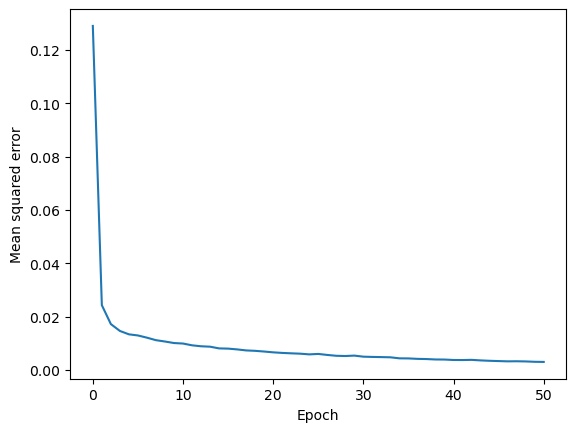

In [20]:
import matplotlib.pyplot as plt

plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
#plt.savefig('figures/11_07.png', dpi=300)
plt.show()

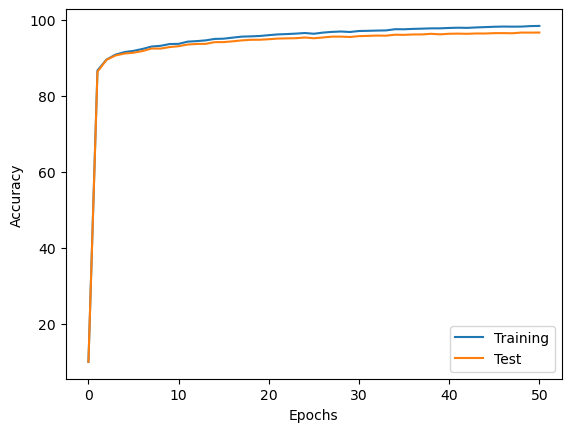

In [21]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_test_acc)), epoch_test_acc,
         label='Test')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
#plt.savefig('figures/11_08.png', dpi=300)
plt.show()

In [22]:
test_mse, test_acc, test_auc = compute_metrics(model, X_test, y_test)
print(f'Test MSE: {test_mse:.2f}')
print(f'Test accuracy: {test_acc*100:.2f}%')
print(f'Test macro AUC: {test_auc:.4f}')

# Save results for later comparison
impl2_results = {
    'model_name': 'Implementation 2: Two Hidden Layers (500 neurons each)',
    'test_mse': test_mse,
    'test_accuracy': test_acc * 100,
    'test_macro_auc': test_auc
}
print(f'\nResults saved for comparison')

Test MSE: 0.01
Test accuracy: 96.67%
Test macro AUC: 0.9985

Results saved for comparison


In [23]:
import pickle
import os

# Create directory for saved models if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save Implementation 2 data
impl2_data = {
    'model_weights': {
        'weight_h1': model.weight_h1,
        'bias_h1': model.bias_h1,
        'weight_h2': model.weight_h2,
        'bias_h2': model.bias_h2,
        'weight_out': model.weight_out,
        'bias_out': model.bias_out
    },
    'results': impl2_results,
    'training_history': {
        'epoch_loss': epoch_loss,
        'epoch_train_acc': epoch_train_acc,
        'epoch_test_acc': epoch_test_acc,
        'epoch_train_auc': epoch_train_auc,
        'epoch_test_auc': epoch_test_auc
    },
    'model_config': {
        'num_features': 28*28,
        'num_hidden1': 500,
        'num_hidden2': 500,
        'num_classes': 10,
        'num_epochs': 50
    }
}

with open('saved_models/impl2_data.pkl', 'wb') as f:
    pickle.dump(impl2_data, f)

print('✓ Implementation 2 model and results saved to saved_models/impl2_data.pkl')

✓ Implementation 2 model and results saved to saved_models/impl2_data.pkl


## Implementation 3: Keras (two hidden layes)

In [27]:
# Fix protobuf compatibility issue, then install TensorFlow
# Uncomment and run these lines:
#!pip install protobuf==3.20.3
#!pip install tensorflow==2.8.0

# IMPORTANT: After running the cell above, restart the kernel before importing TensorFlow!

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(123)
np.random.seed(123)

# IMPORTANT: Use the same weight initialization as custom implementations
# Custom implementations use: normal(loc=0.0, scale=0.1)
# This ensures fair comparison
weight_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.1, seed=123)
bias_init = keras.initializers.Zeros()

# Convert labels to one-hot encoding (needed for evaluation)
y_train_onehot = tf.one_hot(y_train, depth=10).numpy()
y_test_onehot = tf.one_hot(y_test, depth=10).numpy()

# Step 1: Create a fresh model to evaluate at epoch 0 (before training)
keras_model_epoch0 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(500, activation="sigmoid", 
                 kernel_initializer=weight_init, 
                 bias_initializer=bias_init),
    layers.Dense(500, activation="sigmoid", 
                 kernel_initializer=weight_init, 
                 bias_initializer=bias_init),
    layers.Dense(10, activation="softmax", 
                 kernel_initializer=weight_init, 
                 bias_initializer=bias_init),
])

keras_model_epoch0.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="mse",
    metrics=['accuracy']
)

# Evaluate at epoch 0 (initial random weights, before any training)
epoch0_train_loss, epoch0_train_acc = keras_model_epoch0.evaluate(X_train, y_train_onehot, verbose=0)
epoch0_val_loss, epoch0_val_acc = keras_model_epoch0.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Epoch 0 (initial random weights):")
print(f"  Train Loss: {epoch0_train_loss:.4f}, Train Acc: {epoch0_train_acc*100:.2f}%")
print(f"  Val Loss: {epoch0_val_loss:.4f}, Val Acc: {epoch0_val_acc*100:.2f}%\n")

# Step 2: Create and train the actual model
keras_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(500, activation="sigmoid", 
                 kernel_initializer=weight_init, 
                 bias_initializer=bias_init),  # hidden layer 1
    layers.Dense(500, activation="sigmoid", 
                 kernel_initializer=weight_init, 
                 bias_initializer=bias_init),  # hidden layer 2
    layers.Dense(10, activation="softmax", 
                 kernel_initializer=weight_init, 
                 bias_initializer=bias_init),   # output layer
])

keras_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="mse",  # MSE loss to match custom implementation
    metrics=['accuracy']
)

# Train the model (this will give us epochs 1-50)
history = keras_model.fit(
    X_train, y_train_onehot,
    epochs=50, 
    batch_size=100,
    validation_data=(X_test, y_test_onehot),
    verbose=1
)

# Step 3: Prepend epoch 0 metrics to history for fair comparison with custom implementations
history.history['loss'] = [epoch0_train_loss] + history.history['loss']
history.history['accuracy'] = [epoch0_train_acc] + history.history['accuracy']
history.history['val_loss'] = [epoch0_val_loss] + history.history.get('val_loss', [])
history.history['val_accuracy'] = [epoch0_val_acc] + history.history['val_accuracy']

print(f"\n✅ Keras history now includes epoch 0 (total: {len(history.history['val_accuracy'])} points)")
print(f"   Aligned with custom implementations for fair comparison!")

# Get predictions
proba_test = keras_model.predict(X_test)  # shape (n_test, 10)

# Calculate macro AUC
from sklearn.metrics import roc_auc_score
keras_macro_auc = roc_auc_score(
    y_test_onehot,
    proba_test,
    multi_class="ovr",
    average="macro"
)

print(f'\nKeras Model Test Macro AUC: {keras_macro_auc:.4f}')



Epoch 0 (initial random weights):
  Train Loss: 0.1041, Train Acc: 3.88%
  Val Loss: 0.1042, Val Acc: 3.80%

Epoch 1/50
490/490 [==============================] - 7s 13ms/step - loss: 0.0864 - accuracy: 0.3098 - val_loss: 0.0810 - val_accuracy: 0.3878
Epoch 2/50
490/490 [==============================] - 7s 14ms/step - loss: 0.0751 - accuracy: 0.4501 - val_loss: 0.0693 - val_accuracy: 0.5417
Epoch 3/50
490/490 [==============================] - 7s 14ms/step - loss: 0.0636 - accuracy: 0.5976 - val_loss: 0.0583 - val_accuracy: 0.6668
Epoch 4/50
490/490 [==============================] - 7s 13ms/step - loss: 0.0534 - accuracy: 0.7067 - val_loss: 0.0489 - val_accuracy: 0.7399
Epoch 5/50
490/490 [==============================] - 7s 13ms/step - loss: 0.0450 - accuracy: 0.7538 - val_loss: 0.0416 - val_accuracy: 0.7677
Epoch 6/50
490/490 [==============================] - 6s 13ms/step - loss: 0.0388 - accuracy: 0.7877 - val_loss: 0.0363 - val_accuracy: 0.8093
Epoch 7/50
490/490 [=============

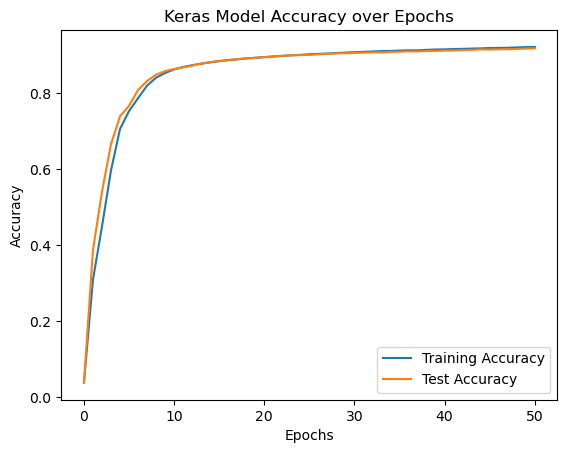

Keras Model Test MSE: 0.01
Keras Model Test Accuracy: 91.88%


In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Keras Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()  

#final test metrics for Keras model
test_loss, test_acc = keras_model.evaluate(X_test, y_test_onehot, verbose=0)
print(f'Keras Model Test MSE: {test_loss:.2f}')
print(f'Keras Model Test Accuracy: {test_acc*100:.2f}%')


In [40]:
# Save results for later comparison
keras_results = {
    'model_name': 'Keras Implementation: Two Hidden Layers (500 neurons each)',
    'test_mse': test_loss,
    'test_accuracy': test_acc * 100,
    'test_macro_auc': keras_macro_auc
}
print(f'\nResults saved for comparison')


Results saved for comparison


In [41]:
import pickle
import os

# Create directory for saved models if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save Keras model
keras_model.save('saved_models/keras_model.h5')

# Save Keras training data
keras_data = {
    'results': keras_results,
    'training_history': {
        'loss': history.history['loss'],
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy']
    },
    'test_probas': proba_test,
    'model_config': {
        'num_features': 28*28,
        'num_hidden1': 500,
        'num_hidden2': 500,
        'num_classes': 10,
        'num_epochs': 50
    }
}

with open('saved_models/keras_data.pkl', 'wb') as f:
    pickle.dump(keras_data, f)

print('✓ Keras model saved to saved_models/keras_model.h5')
print('✓ Keras training data saved to saved_models/keras_data.pkl')

✓ Keras model saved to saved_models/keras_model.h5
✓ Keras training data saved to saved_models/keras_data.pkl


## Compare all implementations

**Note:** This comparison section can run independently by loading saved model data from the previous implementations.

In [42]:
import pickle
import os

# Load saved data from all implementations
print('Loading saved model data...')

# Load Implementation 1
with open('saved_models/impl1_data.pkl', 'rb') as f:
    impl1_data = pickle.load(f)
impl1_results = impl1_data['results']
impl1_history = impl1_data['training_history']
print('✓ Implementation 1 data loaded')

# Load Implementation 2
with open('saved_models/impl2_data.pkl', 'rb') as f:
    impl2_data = pickle.load(f)
impl2_results = impl2_data['results']
impl2_history = impl2_data['training_history']
print('✓ Implementation 2 data loaded')

# Load Keras Implementation
with open('saved_models/keras_data.pkl', 'rb') as f:
    keras_data = pickle.load(f)
keras_results = keras_data['results']
keras_history = keras_data['training_history']
print('✓ Keras implementation data loaded')

print('\nAll model data loaded successfully!')

Loading saved model data...
✓ Implementation 1 data loaded
✓ Implementation 2 data loaded
✓ Keras implementation data loaded

All model data loaded successfully!


### Summary Table

In [43]:
import pandas as pd
import numpy as np

# Create comparison dataframe
comparison_data = {
    'Implementation': [],
    'Hidden Layers': [],
    'Neurons per Layer': [],
    'Epochs': [],
    'Test MSE': [],
    'Test Accuracy (%)': [],
    'Test Macro AUC': []
}

# Implementation 1
comparison_data['Implementation'].append('Original (Single Layer)')
comparison_data['Hidden Layers'].append(1)
comparison_data['Neurons per Layer'].append(50)
comparison_data['Epochs'].append(50)
comparison_data['Test MSE'].append(impl1_results['test_mse'])
comparison_data['Test Accuracy (%)'].append(impl1_results['test_accuracy'])
comparison_data['Test Macro AUC'].append(impl1_results['test_macro_auc'])

# Implementation 2
comparison_data['Implementation'].append('Revised (Two Layers)')
comparison_data['Hidden Layers'].append(2)
comparison_data['Neurons per Layer'].append('500 + 500')
comparison_data['Epochs'].append(50)
comparison_data['Test MSE'].append(impl2_results['test_mse'])
comparison_data['Test Accuracy (%)'].append(impl2_results['test_accuracy'])
comparison_data['Test Macro AUC'].append(impl2_results['test_macro_auc'])

# Keras Implementation
comparison_data['Implementation'].append('Keras (Two Layers)')
comparison_data['Hidden Layers'].append(2)
comparison_data['Neurons per Layer'].append('500 + 500')
comparison_data['Epochs'].append(50)
comparison_data['Test MSE'].append(keras_results['test_mse'])
comparison_data['Test Accuracy (%)'].append(keras_results['test_accuracy'])
comparison_data['Test Macro AUC'].append(keras_results['test_macro_auc'])

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

         Implementation  Hidden Layers Neurons per Layer  Epochs  Test MSE  Test Accuracy (%)  Test Macro AUC
Original (Single Layer)              1                50      50  0.009508          94.490476        0.992598
   Revised (Two Layers)              2         500 + 500      50  0.005166          96.666667        0.998528
     Keras (Two Layers)              2         500 + 500      50  0.012747          91.876191        0.992692


### Training Curves Comparison

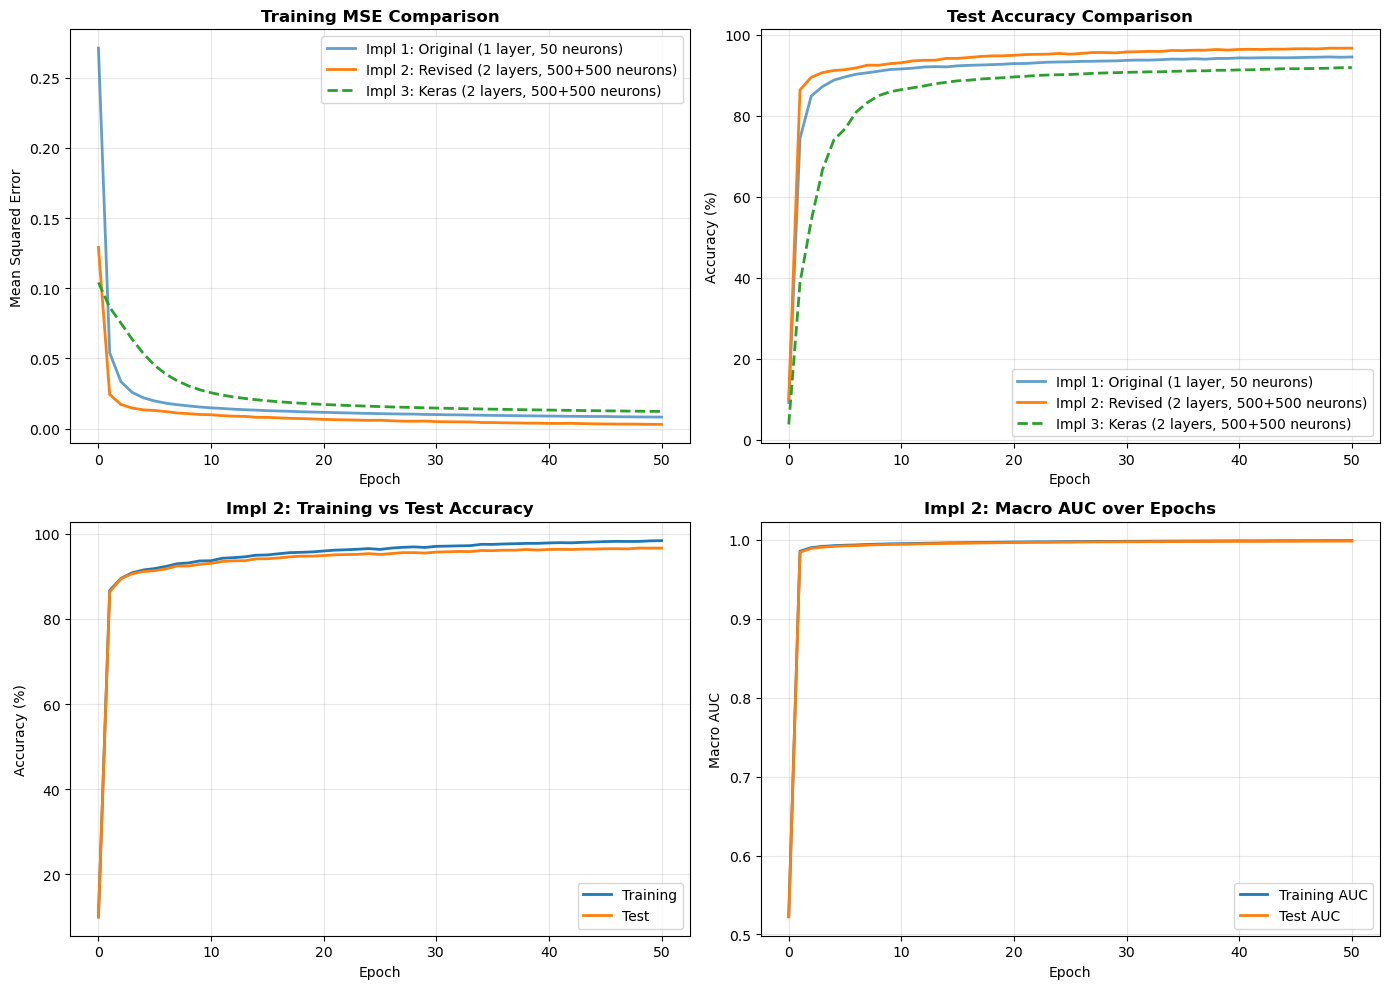

In [44]:
import matplotlib.pyplot as plt

# Note: All implementations trained for 50 epochs
# Different starting points are due to different random weight initializations

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training MSE - All implementations
axes[0, 0].plot(range(len(impl1_history['epoch_loss'])), impl1_history['epoch_loss'], 
                label='Impl 1: Original (1 layer, 50 neurons)', linewidth=2, alpha=0.7)
axes[0, 0].plot(range(len(impl2_history['epoch_loss'])), impl2_history['epoch_loss'], 
                label='Impl 2: Revised (2 layers, 500+500 neurons)', linewidth=2)
axes[0, 0].plot(range(len(keras_history['loss'])), keras_history['loss'], 
                label='Impl 3: Keras (2 layers, 500+500 neurons)', linewidth=2, linestyle='--')
axes[0, 0].set_title('Training MSE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Mean Squared Error')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Test Accuracy - All implementations
axes[0, 1].plot(range(len(impl1_history['epoch_test_acc'])), impl1_history['epoch_test_acc'], 
                label='Impl 1: Original (1 layer, 50 neurons)', linewidth=2, alpha=0.7)
axes[0, 1].plot(range(len(impl2_history['epoch_test_acc'])), impl2_history['epoch_test_acc'], 
                label='Impl 2: Revised (2 layers, 500+500 neurons)', linewidth=2)
axes[0, 1].plot(range(len(keras_history['val_accuracy'])), 
                [acc*100 for acc in keras_history['val_accuracy']], 
                label='Impl 3: Keras (2 layers, 500+500 neurons)', linewidth=2, linestyle='--')
axes[0, 1].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training vs Test Accuracy (Implementation 2)
axes[1, 0].plot(range(len(impl2_history['epoch_train_acc'])), impl2_history['epoch_train_acc'], 
                label='Training', linewidth=2)
axes[1, 0].plot(range(len(impl2_history['epoch_test_acc'])), impl2_history['epoch_test_acc'], 
                label='Test', linewidth=2)
axes[1, 0].set_title('Impl 2: Training vs Test Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Macro AUC over epochs (Implementation 2)
axes[1, 1].plot(range(len(impl2_history['epoch_train_auc'])), impl2_history['epoch_train_auc'], 
                label='Training AUC', linewidth=2)
axes[1, 1].plot(range(len(impl2_history['epoch_test_auc'])), impl2_history['epoch_test_auc'], 
                label='Test AUC', linewidth=2)
axes[1, 1].set_title('Impl 2: Macro AUC over Epochs', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Macro AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('figures/11_comparison.png', dpi=300)
plt.show()

### Final Test Metrics Bar Chart

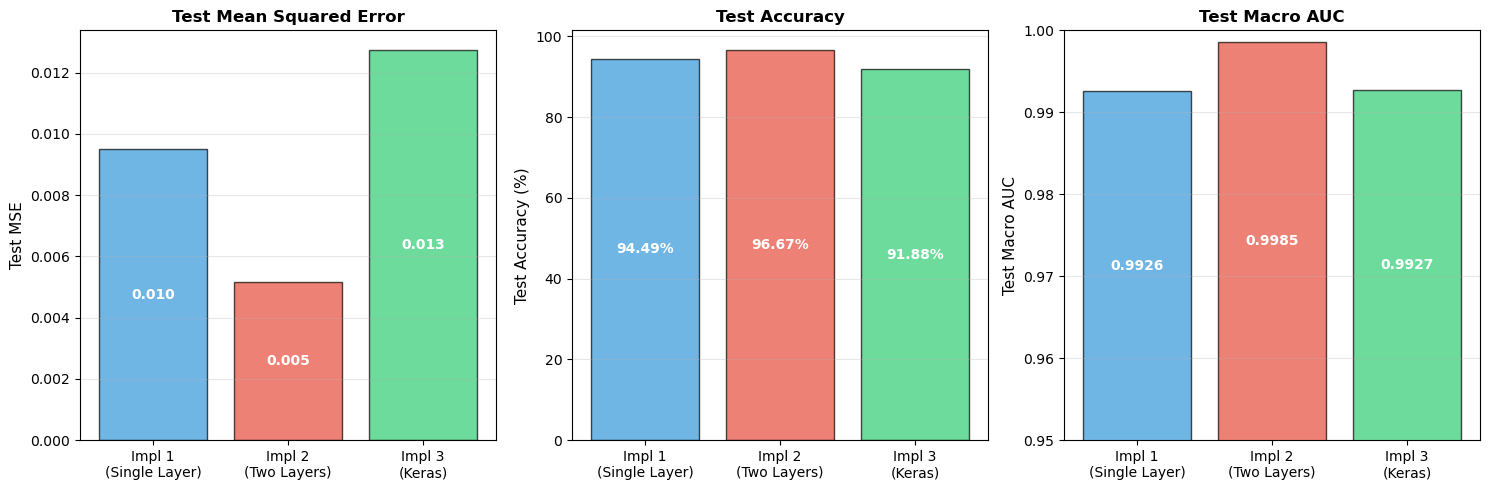

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Create bar chart comparing final test metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

implementations = ['Impl 1\n(Single Layer)', 'Impl 2\n(Two Layers)', 'Impl 3\n(Keras)']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Test MSE
test_mses = [impl1_results['test_mse'], impl2_results['test_mse'], keras_results['test_mse']]
axes[0].bar(implementations, test_mses, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test MSE', fontsize=11)
axes[0].set_title('Test Mean Squared Error', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_mses):
    axes[0].text(i, v * 0.5, f'{v:.3f}', ha='center', va='center', fontweight='bold', color='white', fontsize=10)

# Test Accuracy
test_accs = [impl1_results['test_accuracy'], impl2_results['test_accuracy'], keras_results['test_accuracy']]
axes[1].bar(implementations, test_accs, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[1].set_title('Test Accuracy', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_accs):
    axes[1].text(i, v * 0.5, f'{v:.2f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=10)

# Test Macro AUC
test_aucs = [impl1_results['test_macro_auc'], impl2_results['test_macro_auc'], keras_results['test_macro_auc']]
axes[2].bar(implementations, test_aucs, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Test Macro AUC', fontsize=11)
axes[2].set_title('Test Macro AUC', fontsize=12, fontweight='bold')
axes[2].set_ylim([0.95, 1.0])  # Focus on the relevant range
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_aucs):
    # For AUC, position relative to the visible range
    axes[2].text(i, 0.95 + (v - 0.95) * 0.5, f'{v:.4f}', ha='center', va='center', fontweight='bold', color='white', fontsize=10)

plt.tight_layout()
#plt.savefig('figures/11_comparison_bars.png', dpi=300)
plt.show()